In [1]:
import numpy as np
import pandas as pd

from tqdm import tqdm

from scipy.stats import zscore
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.special import logsumexp

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook', font_scale=1.5)
import plotly.graph_objects as go

from core import *

In [11]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
DATA_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
SESSION_NAME = "pre_sleep_g0"
BASE_NAME = "Bilat_R02_20251106"
PROBES = [0, 1, 2, 3]


# Spike rate computation parameters
WINDOW_SIZE = 0.04          # s
STEP_SIZE   = 0.04        # s
SIGMA       = 12.5          # smoothing sigma (0 -> no smoothing)
USE_UNITS   = "good"       # {'all', 'good', 'mua'}
NORMALIZE   = False         # z-score each unit's rates

# Filtering thresholds
MIN_TOTAL_SPIKES   = 100
MIN_MEAN_RATE_HZ   = 0.01
MIN_PRESENCE_RATIO = 0.25
N_TIME_BINS        = 100    # coarse bins for presence ratio


# defining the region dictionary. Keys are probe numbers, values are dictionaries which are further mapping shanks to regions
#region_dict = {0: {0: 'CA1', 1: 'RSP', 2: 'CA3', 3: 'CA1', 4: 'RSP', 5: 'CA3', 6: 'CA1', 7: 'RSP'}, 1: {0: 'CA3', 1: 'CA1', 2: 'CA2', 3: 'A1', 4: 'S1'}, 2: {0: 'CA3', 1: 'Th', 2: 'V1', 3: 'Th', 4: 'CA1', 5: 'V1', 6: 'CA1', 7: 'V1'}} UDS
region_dict = {
    0: {0: 'CA1', 1: 'Th', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1', 8: 'CA1', 9: 'CA1', 10: 'CA1', 11: 'CA1', 12: 'Th'},
    3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1', 8: 'CA1', 9: 'CA1', 10: 'CA1', 11: 'CA1', 12: 'CA1', 13: 'CA1', 14: 'CA1', 15: 'CA1'}
}

#region_dict = {
    #0: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    ##1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    #2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1', 8: 'CA1', 9: 'CA1', 10: 'CA1', 11: 'CA1', 12: 'CA1'},
    #3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1', 8: 'CA1', 9: 'CA1', 10: 'CA1', 11: 'CA1', 12: 'CA1', 13: 'CA1', 14: 'CA1', 15: 'CA1'}
#}

# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
hemisphere_dict = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}

In [12]:

def load_cell_metrics_aligned(cell_metrics_file, units_from_rates, region_dict_for_probe):
    """
    Align cell_metrics rows to the *row order* of your rate matrix (units_from_rates).
    Returns dict with ordered arrays: cell_type, shank_id, region, cluID, UID, row_idx_in_cm.
    """
    cm = loadmat(cell_metrics_file)['cell_metrics']
    # Pull fields
    cm_UID    = cm['UID'][0,0].flatten()               # 1..N (row index in cm)
    cm_cluID  = cm['cluID'][0,0].flatten()             # Kilosort cluster IDs (matches `units`)
    cm_ct_raw = cm['putativeCellType'][0,0].flatten()  # object array of strings
    cm_shank  = cm['shankID'][0,0].flatten()           # 1-based shank ids

    # Normalize strings (CellExplorer stores as 1x1 object arrays sometimes)
    cm_ct = np.array([ct[0] if isinstance(ct, np.ndarray) else ct for ct in cm_ct_raw])

    # Build mapping from cluster ID -> row in cell_metrics
    id_to_row = {int(k): i for i, k in enumerate(cm_cluID)}

    # Reorder cm rows to match your rate-matrix row order exactly
    try:
        rows = np.array([id_to_row[int(u)] for u in units_from_rates], dtype=int)
    except KeyError as e:
        missing = int(e.args[0])
        raise RuntimeError(
            f"Cluster ID {missing} (from rate matrix) not found in cell_metrics['cluID']. "
            "Make sure your compute_spike_rates `use_units` filter matches the cell_metrics set."
        )

    cell_type = cm_ct[rows]
    shank_id  = cm_shank[rows]                    # still 1-based
    UID       = cm_UID[rows]                      # 1..N order aligned to rates
    cluID     = cm_cluID[rows]                    # should equal units_from_rates
    region    = np.array([region_dict_for_probe[s-1] for s in shank_id])  # shank->region

    # Sanity checks
    assert len(units_from_rates) == cell_type.size == shank_id.size == region.size
    assert np.all(cluID == units_from_rates), "Aligned cluID does not match rate-matrix units order."

    return dict(
        row_idx_in_cm=rows,
        UID=UID,
        cluID=cluID,
        cell_type=cell_type,
        shank_id=shank_id,
        region=region
    )

In [13]:
# ------------------------ Load spike rate matrices ------------------------
spike_rate_matrices = {}
cell_types = {}
regions = {}
shanks = {}
for probe in PROBES:
    # Get the raw spike counts and the zscored and smoothed spike rates
    ks_dir = os.path.join(DATA_DIR, f'Kilosort_imec{probe}_ks4')
    raw_rates, time_bins, units = compute_spike_rates(str(ks_dir), WINDOW_SIZE, STEP_SIZE, USE_UNITS, 0.0, False)
    spike_rate_matrix, _, _ = compute_spike_rates(str(ks_dir), WINDOW_SIZE, STEP_SIZE, USE_UNITS, SIGMA, NORMALIZE)
    est_counts_per_bin = raw_rates * WINDOW_SIZE


    # computing the filtering metrics
    total_spikes   = est_counts_per_bin.sum(axis=1)         
    mean_rate_hz   = raw_rates.mean(axis=1)
    presence_ratio = get_presence_ratio(est_counts_per_bin, time_bins, N_TIME_BINS)

    mask = (
        (total_spikes >= MIN_TOTAL_SPIKES) &
        (mean_rate_hz >= MIN_MEAN_RATE_HZ) &
        (presence_ratio >= MIN_PRESENCE_RATIO)
    )


    # Apply mask to spike rate matrix and unit list
    spike_rate_matrix = spike_rate_matrix[mask, :]
    units = [u for u, keep in zip(units, mask) if keep]
    print(f"Probe {probe}: Keeping {mask.sum()} / {mask.sum() + (~mask).sum()} units after filtering.\nspike_rate_matrix shape: {spike_rate_matrix.shape}\n")

    # remove units based on presence ratio
    spike_rate_matrices[probe] = (spike_rate_matrix, time_bins, units)


    # Load the cell metrics
    cell_metrics_file = os.path.join(DATA_DIR, f'{BASE_NAME}_imec{probe}.cell_metrics.cellinfo.mat')
    meta = load_cell_metrics_aligned(cell_metrics_file, units, region_dict[probe])

    cell_type = meta['cell_type']
    shank_ids = meta['shank_id']
    regions[probe] = meta['region']
    shanks[probe] = shank_ids
    cell_types[probe] = cell_type
    


# Make a dictionary to store each units index, region, hemisphere and shank ID. Also build a global unit list
unit_info = {}
global_unit_list = []
for probe in PROBES:
    _, _, units = spike_rate_matrices[probe]
    hemi = hemisphere_dict[probe]
    cell_type = cell_types[probe]
    region = regions[probe]
    shank = shanks[probe]

    for i, unit in enumerate(units):
        global_unit_list.append((probe, unit))
        unit_info[(probe, unit)] = {
            'index': i,
            'region': region[i],
            'hemisphere': hemi,
            'cell_type': cell_type[i],
            'shank': shank[i]
        }

Probe 0: Keeping 55 / 60 units after filtering.
spike_rate_matrix shape: (55, 263023)

Probe 1: Keeping 41 / 41 units after filtering.
spike_rate_matrix shape: (41, 263023)

Probe 2: Keeping 248 / 275 units after filtering.
spike_rate_matrix shape: (248, 263027)

Probe 3: Keeping 200 / 208 units after filtering.
spike_rate_matrix shape: (200, 263027)



Number of TTLs: 240196
Number of frames: 308232
Trimming frames from 308232 to 240196
Tracking start time: 3913.393 s, end time: 6495.247 s, duration: 2581.854 s


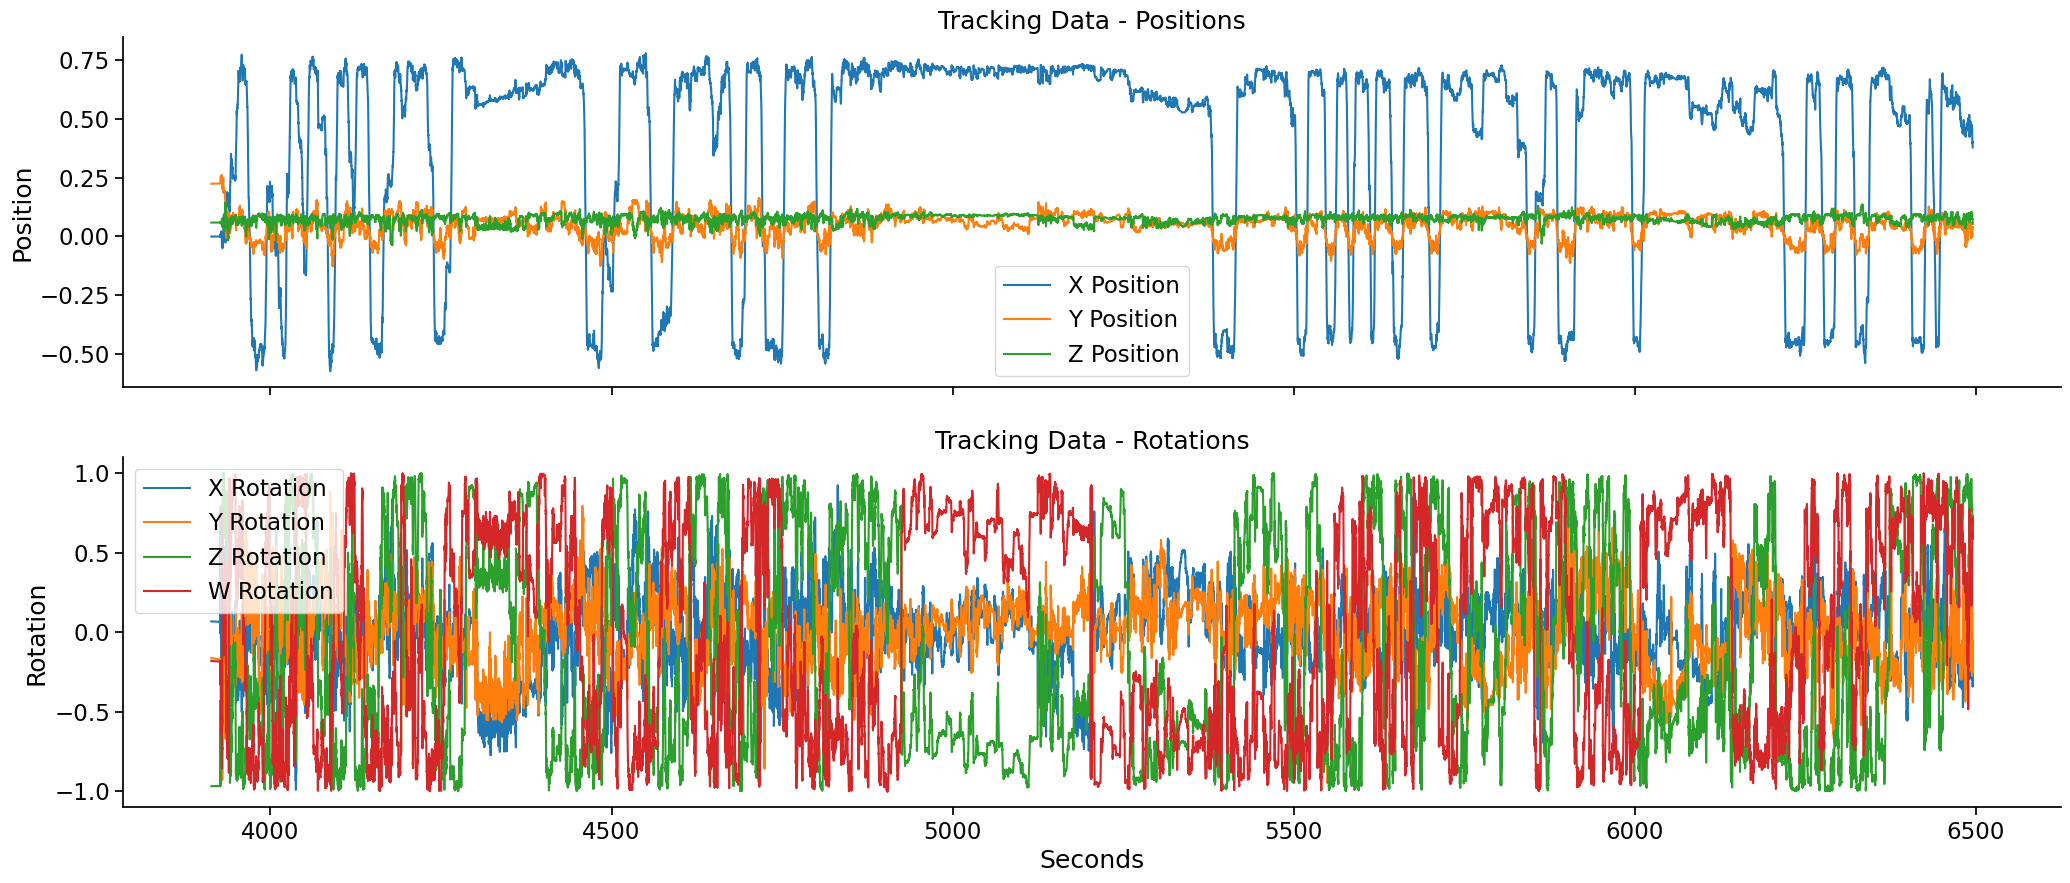

In [14]:
# Loadding in the TTLs
ttl_file = os.path.join(DATA_DIR, 'preprocessing_output', f'supercat_{SESSION_NAME}', f'{SESSION_NAME}_tcat.obx0.obx.xd_6_12_0.txt')
ttls = np.loadtxt(ttl_file)
print(f"Number of TTLs: {len(ttls)}")

# Loadding in the tracking data
tracking_file = os.path.join(DATA_DIR, "Bilat_R02_20251106_linear_maze_000.csv")
tracking_data = np.genfromtxt(tracking_file, delimiter=",", skip_header=7)
frames = tracking_data[:,0]
print(f'Number of frames: {len(frames)}')


# Sometimes there are a few more frames after the last TTL or more TTLs than frames. We will trim the data to the shortest length.
if len(frames) < len(ttls):
    print(f'Trimming TTLs from {len(ttls)} to {len(frames)}')
    ttls = ttls[:len(frames)]
    tracking_data = tracking_data[:len(frames),:]
elif len(frames) > len(ttls):
    print(f'Trimming frames from {len(frames)} to {len(ttls)}')
    frames = frames[:len(ttls)]
    tracking_data = tracking_data[:len(ttls),:]

# printing the start and end times
print(f'Tracking start time: {ttls[0]:.3f} s, end time: {ttls[-1]:.3f} s, duration: {ttls[-1]-ttls[0]:.3f} s')


# fill missing values or nan with linear interpolation
for i in range(tracking_data.shape[1]):
    col = tracking_data[:,i]
    nans = np.isnan(col)
    if np.any(nans):
        not_nans = ~nans
        interp_func_col = interp1d(frames[not_nans], col[not_nans], bounds_error=False, fill_value="extrapolate")
        col[nans] = interp_func_col(frames[nans])
        tracking_data[:,i] = col

# extract x, y, z positions and rotations
x_rotations = tracking_data[:,2]
y_rotations = tracking_data[:,3]
z_rotations = tracking_data[:,4]
w_rotations = tracking_data[:,5]
x_positions = tracking_data[:,6]
y_positions = tracking_data[:,7]
z_positions = tracking_data[:,8]

# Plotting the tracking data
fig, axs = plt.subplots(2, 1, figsize=(25,10), sharex=True)

sns.lineplot(ax=axs[0], x=ttls, y=x_positions, label='X Position')
sns.lineplot(ax=axs[0], x=ttls, y=y_positions, label='Y Position')
sns.lineplot(ax=axs[0], x=ttls, y=z_positions, label='Z Position')
axs[0].set_ylabel('Position')
axs[0].set_title('Tracking Data - Positions')

sns.lineplot(ax=axs[1], x=ttls, y=x_rotations, label='X Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=y_rotations, label='Y Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=z_rotations, label='Z Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=w_rotations, label='W Rotation')
axs[1].set_xlabel('Seconds')
axs[1].set_ylabel('Rotation')
axs[1].set_title('Tracking Data - Rotations')
sns.despine()
plt.show()


In [15]:
# choose which position to use
pos_raw = x_positions  # original position samples aligned to `frames` (units: cm)
assert frames.shape[0] == pos_raw.shape[0]

# compute the velocity
velocity = np.gradient(pos_raw) / np.gradient(ttls)  # velocity in m/s

# getting the running direction
running_direction = np.sign(velocity)

# getting the speed
speed = np.abs(velocity)  # speed in m/s

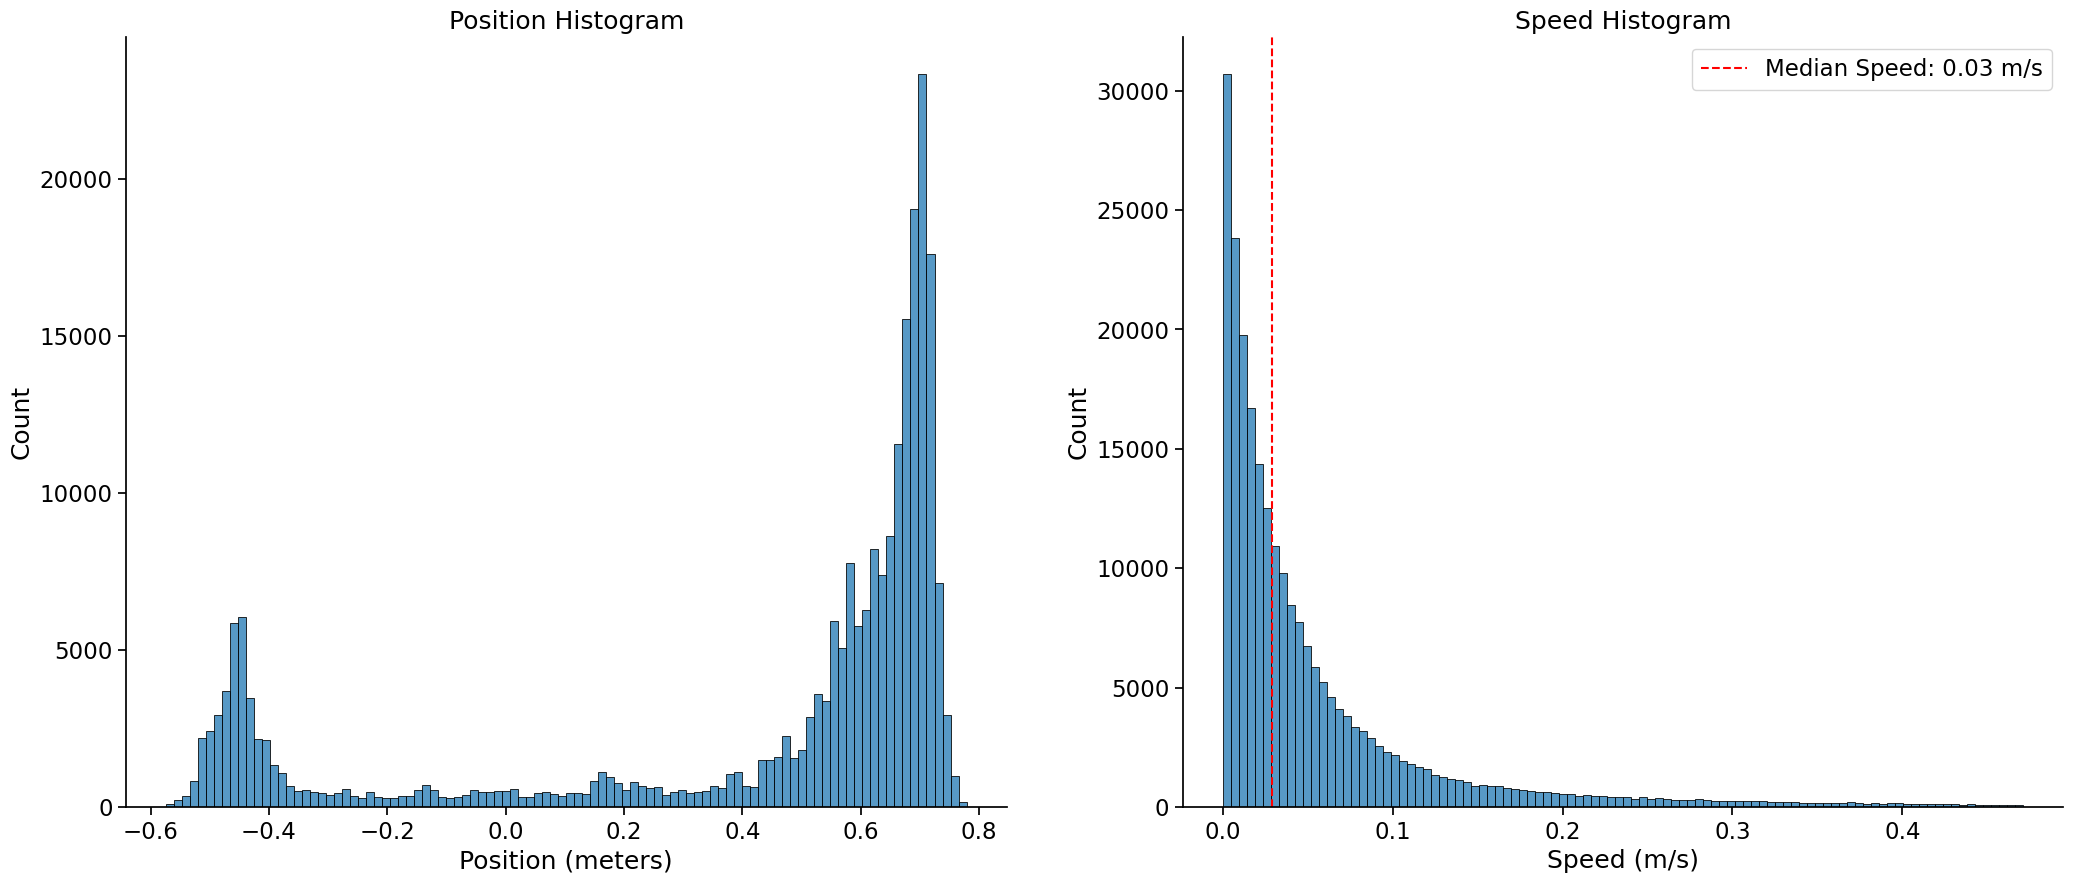

In [16]:
# Plotting some position statistics
fig, axs = plt.subplots(1, 2, figsize=(25,10))
sns.histplot(ax=axs[0], x=pos_raw, bins=100)
axs[0].set_xlabel('Position (meters)')
axs[0].set_ylabel('Count')
axs[0].set_title('Position Histogram')

sns.histplot(ax=axs[1], x=speed[speed < np.percentile(speed, 99)], bins=100)
axs[1].set_xlabel('Speed (m/s)')
axs[1].set_ylabel('Count')
axs[1].set_title('Speed Histogram')
axs[1].axvline(x = np.median(speed), color='red', linestyle='--', label=f'Median Speed: {np.median(speed):.2f} m/s')
axs[1].legend()
sns.despine()
plt.show()


In [17]:
# -----------------------
# Config
# -----------------------
n_spatial_bins = 100
pos_min, pos_max = -0.5, 0.7
speed_threshold = 0.03  # m/s
regions_of_interest = ['CA1']
cell_type_groups = {
    'Pyramidal':   ['Pyramidal Cell'],
    'Interneuron': ['Narrow Interneuron', 'Wide Interneuron'],
}
bin_edges = np.linspace(pos_min, pos_max, n_spatial_bins + 1)

# Position interpolation on a canonical timebase will be done per-probe below
pos_interp_func = interp1d(ttls, pos_raw, bounds_error=False, fill_value=np.nan)

# Helper: Skaggs SI (bits/spike) on one unit
def unit_place_field_and_si(fr_unit, idx, denom, info_mode='per_spike'):
    num = np.bincount(idx, weights=fr_unit, minlength=n_spatial_bins).astype(float)
    pf  = np.divide(num, denom, out=np.zeros_like(num), where=(denom > 0))

    occ_mask = denom > 0
    if not np.any(occ_mask) or np.all(pf[occ_mask] == 0):
        return pf, 0.0

    p_i   = denom[occ_mask] / np.sum(denom[occ_mask])
    r_i   = pf[occ_mask]
    r_bar = np.sum(p_i * r_i)
    if r_bar <= 0:
        return pf, 0.0

    ratio = r_i / (r_bar + 1e-12)
    I_spike = np.sum(p_i * ratio * np.log2(ratio + 1e-12))
    if info_mode == 'per_spike':
        si = float(I_spike)
    elif info_mode == 'per_second':
        si = float(r_bar * I_spike)
    else:
        raise ValueError("info_mode must be 'per_spike' or 'per_second'.")
    return pf, si

# -----------------------
# Precompute per-probe masks, occupancy, and SI per unit
# -----------------------
# Expecting: spike_rate_matrices[probe]['raw'] etc. (from earlier corrected loader)
si_records = []  # list of dicts: one row per unit with SI and metadata

# (Optional) PFs for heatmaps grouped by (celltype, region, hemisphere)
panel_pfs = {}  # key: (row_key, col_key, hemi) -> list of PFs
for hemi in ['L', 'R']:
    for rkey, allowed_ct in cell_type_groups.items():
        for ckey in regions_of_interest:
            panel_pfs[(rkey, ckey, hemi)] = []

for probe in PROBES:
    # --- fetch per-probe data
    raw_rates = spike_rate_matrices[probe][0]         # (n_units, T)
    tb        = spike_rate_matrices[probe][1]   # (T,)
    units     = spike_rate_matrices[probe][2]       # (n_units,)
    ct_arr    = np.asarray(cell_types[probe])             # (n_units,)
    rgn_arr   = np.asarray(regions[probe])                # (n_units,)
    shk_arr   = np.asarray(shanks[probe])                 # (n_units,)
    hemi      = hemisphere_dict[probe]                    # 'L' or 'R'

    # --- position to this probe’s time grid, TTL crop, NaN drop, speed mask
    pos_probe = pos_interp_func(tb)

    start_time, end_time = np.min(ttls), np.max(ttls)
    valid_time = (tb >= start_time) & (tb <= end_time)

    pos_crop = pos_probe[valid_time]
    tb_crop  = tb[valid_time]
    fr       = raw_rates[:, valid_time]

    ok = ~np.isnan(pos_crop)
    if ok.sum() == 0:
        print(f"Probe {probe}: no valid samples after TTL/position masking.")
        continue
    pos_crop = pos_crop[ok]
    tb_crop  = tb_crop[ok]
    fr       = fr[:, ok]

    speed = np.abs(np.gradient(pos_crop, tb_crop))
    speed = gaussian_filter1d(speed, sigma=3)
    move  = speed > speed_threshold
    if move.sum() == 0:
        print(f"Probe {probe}: no samples exceed speed threshold ({speed_threshold} m/s).")
        continue
    pos_m = pos_crop[move]
    tb_m  = tb_crop[move]
    fr_m  = fr[:, move]

    # --- Bin position and occupancy
    idx = np.digitize(pos_m, bin_edges, right=True)
    idx = np.clip(idx, 0, n_spatial_bins - 1)
    denom = np.bincount(idx, minlength=n_spatial_bins).astype(float)
    if denom.sum() == 0:
        print(f"Probe {probe}: zero occupancy across all bins.")
        continue

    # --- Compute PF & SI per unit
    for i in range(fr_m.shape[0]):
        pf, si = unit_place_field_and_si(fr_m[i, :], idx, denom, info_mode='per_spike')

        # record
        si_records.append(dict(
            probe=probe,
            hemisphere=hemi,
            unit_id=int(units[i]),
            unit_index=i,
            shank=int(shk_arr[i]),
            region=str(rgn_arr[i]),
            cell_type=str(ct_arr[i]),
            si_bits_spike=float(si)
        ))

        # optional: stash PFs for heatmaps by (celltype group, region, hemisphere)
        if rgn_arr[i] in regions_of_interest:
            # putative group name
            rkey = 'Pyramidal' if ct_arr[i] in cell_type_groups['Pyramidal'] else \
                   'Interneuron' if ct_arr[i] in cell_type_groups['Interneuron'] else None
            if rkey is not None:
                panel_pfs[(rkey, str(rgn_arr[i]), hemi)].append(pf)

# -----------------------
# (Optional) Build concatenated PF matrices for later plotting
# -----------------------
panel_mats = {}
all_vals = []
for hemi in ['L', 'R']:
    for rkey in cell_type_groups.keys():
        for ckey in regions_of_interest:
            pf_list = panel_pfs[(rkey, ckey, hemi)]
            if len(pf_list) == 0:
                panel_mats[(rkey, ckey, hemi)] = None
                continue
            M = np.vstack(pf_list)
            order = np.argsort(np.argmax(M, axis=1))[::-1]
            M = M[order, :]
            panel_mats[(rkey, ckey, hemi)] = M
            all_vals.append(M.ravel())

if all_vals:
    all_vals = np.concatenate(all_vals)
    vmin = np.percentile(all_vals, 2.5)
    vmax = np.percentile(all_vals, 97.5)
    if vmin == vmax:
        vmax = vmin + 1e-12


probe  shank
0      1         16
       3          5
       4         19
1      1         15
       2         14
       3          6
       4          6
2      1         42
       2         54
       3         25
       4        127
3      1         31
       2         46
       3         64
       4         59
Name: si_bits_spike, dtype: int64


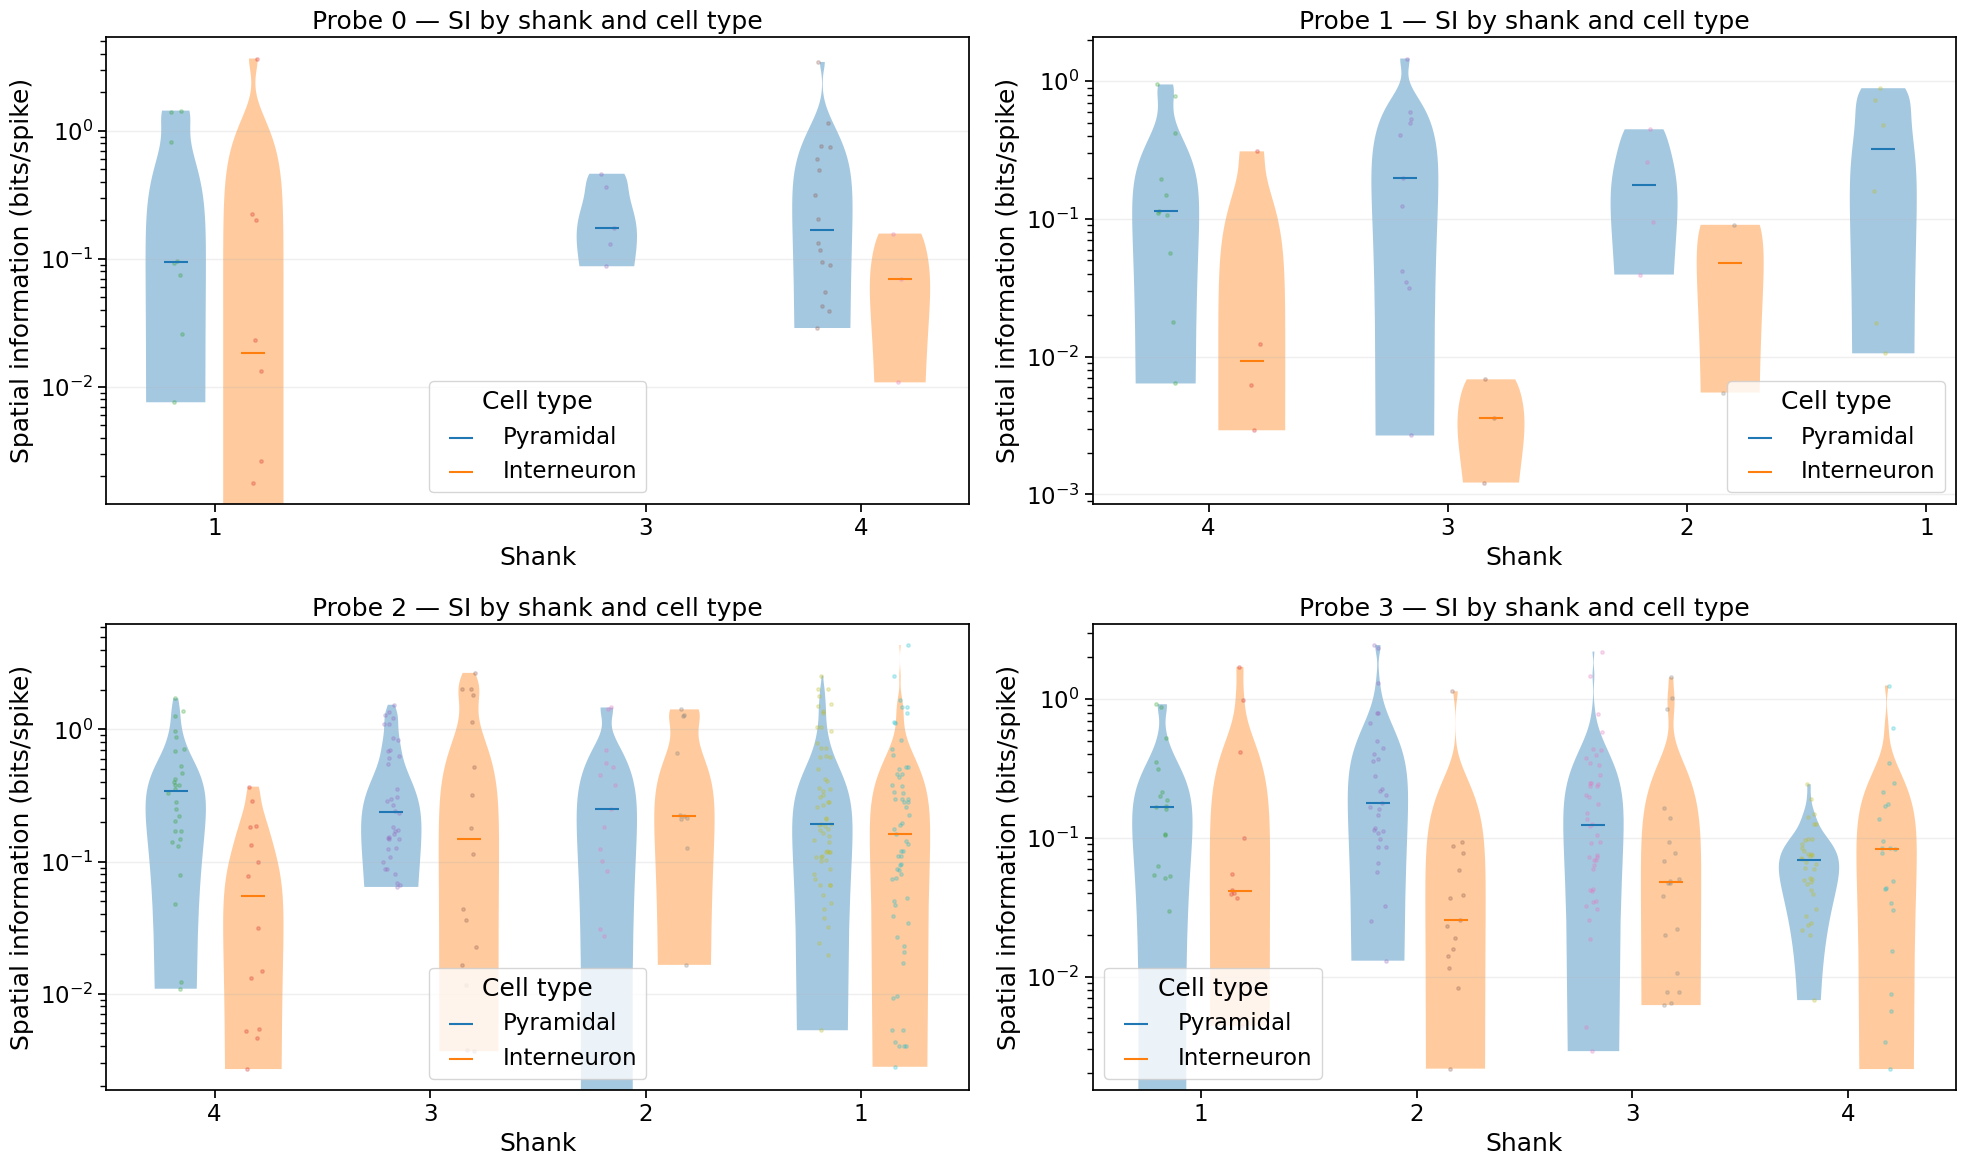

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# si_df must have at least these columns: ['probe','shank','cell_type','si_bits_spike','region']
# Optionally also 'hemisphere'. Filter to your ROI:
si_df = pd.DataFrame(si_records)
si_df_plot = si_df[si_df['region'].isin(regions_of_interest)].copy()

# Sanity check: you should see 4 probes x 4 shanks (if present)
print(si_df_plot.groupby(['probe','shank'])['si_bits_spike'].count())

probes = sorted(si_df_plot['probe'].unique())
celltype_panels = {
    'Pyramidal':   set(cell_type_groups['Pyramidal']),
    'Interneuron': set(cell_type_groups['Interneuron']),
}

nP = len(probes)
ncols = int(np.ceil(np.sqrt(nP)))
nrows = int(np.ceil(nP / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols, 6*nrows), squeeze=False)

for ax, probe in itertools.zip_longest(axes.ravel(), probes, fillvalue=None):
    if probe is None:
        ax.axis('off'); 
        continue

    sub = si_df_plot[si_df_plot['probe'] == probe].copy()
    if sub.empty:
        ax.set_title(f'Probe {probe} (no data)'); 
        ax.axis('off'); 
        continue

    shanks_sorted = sorted(sub['shank'].unique())
    delta = 0.18

    # Collect data & positions, skipping empty groups
    data_left,  pos_left  = [], []
    data_right, pos_right = [], []

    for s in shanks_sorted:
        vals_pyr = sub[(sub['shank'] == s) & (sub['cell_type'].isin(celltype_panels['Pyramidal']))]['si_bits_spike'].values
        vals_int = sub[(sub['shank'] == s) & (sub['cell_type'].isin(celltype_panels['Interneuron']))]['si_bits_spike'].values

        if vals_pyr.size > 0:
            data_left.append(vals_pyr)
            pos_left.append(s - delta)
        if vals_int.size > 0:
            data_right.append(vals_int)
            pos_right.append(s + delta)

    # If both are empty for all shanks, skip this panel
    if (len(data_left) == 0) and (len(data_right) == 0):
        ax.set_title(f'Probe {probe} (no SI data)'); 
        ax.axis('off'); 
        continue

    # Plot violins for non-empty groups
    if len(data_left) > 0:
        v1 = ax.violinplot(data_left, positions=pos_left, widths=0.28, showextrema=False)
        for pc in v1['bodies']: pc.set_alpha(0.4)
        med_left = [np.median(x) for x in data_left]
        ax.scatter(pos_left, med_left, s=300, zorder=3, label='Pyramidal', marker='_')

    if len(data_right) > 0:
        v2 = ax.violinplot(data_right, positions=pos_right, widths=0.28, showextrema=False)
        for pc in v2['bodies']: pc.set_alpha(0.4)
        med_right = [np.median(x) for x in data_right]
        ax.scatter(pos_right, med_right, s=300, zorder=3, label='Interneuron', marker='_')

    # Overlay all individual points (jittered) for transparency
    jitter = 0.04
    for s in shanks_sorted:
        pts_pyr = sub[(sub['shank'] == s) & (sub['cell_type'].isin(celltype_panels['Pyramidal']))]['si_bits_spike'].values
        if pts_pyr.size > 0:
            ax.scatter(s - delta + np.random.uniform(-jitter, jitter, size=pts_pyr.size),
                       pts_pyr, s=6, alpha=0.25)
        pts_int = sub[(sub['shank'] == s) & (sub['cell_type'].isin(celltype_panels['Interneuron']))]['si_bits_spike'].values
        if pts_int.size > 0:
            ax.scatter(s + delta + np.random.uniform(-jitter, jitter, size=pts_int.size),
                       pts_int, s=6, alpha=0.25)

    ax.set_xticks(shanks_sorted)
    ax.set_xlabel('Shank')
    ax.set_ylabel('Spatial information (bits/spike)')
    ax.set_title(f'Probe {probe} — SI by shank and cell type')
    ax.grid(alpha=0.2, axis='y')
    ax.set_yscale('log')

    if probe == probes[1] or probe == probes[2]:
        ax.set_xticks([1,2,3,4], [4, 3,2,1,])


    # Clean legend (only if something was plotted)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), title='Cell type')

plt.tight_layout()

#save as svg
plt.savefig('spatial_information_by_shank_and_celltype.svg', format='svg')

plt.show()